# HVAC vs HVDC Systems

Technology decisions have an impact on a wind project's CapEx. This example will provide a basic
setup to compare how different project sizes, export cable types (HVDC or HVDC), distances to shore,
and etc. effect project costs. Instead of other guides' approach of using the `ExportSystemDesign`,
this will highlight the use of the `ElectricalDesign` model that co-designs the substation
and export cabling system.

In [1]:
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from ORBIT.phases.design import ElectricalDesign
from ORBIT import ProjectManager, ParametricManager

# Apply thousands separators and no decimals to floats
pd.options.display.float_format = '{:,.0f}'.format

## Setup The Models

Here we will setup a base configuration for use with `ProjectManager` plus additional configurations
for running in the `ParametericManager` to look at the cost tradeoffs in export cable types
depending on project size.
Config must include all required variables except those you plan to vary. In this example, we will be manually vary the cable type and then use the `ParametricManager` to vary cable type and plant capacity.

In [2]:
base_config = {
    "export_cable_install_vessel": "example_cable_lay_vessel",
    "site": {
        "distance": 100,
        "depth": 20,
        "distance_to_landfall": 80,
    },
    "plant": {
        "capacity": 1000,
    },
    "turbine": "12MW_generic",
    "oss_install_vessel": "example_heavy_lift_vessel",
    "feeder": "future_feeder",
    "design_phases": [
        "ElectricalDesign",
    ],
    "install_phases": [
        "ExportCableInstallation",
        "OffshoreSubstationInstallation",
    ],
}

Now we can create an HVAC and HVDC variation of the `base_config`

In [3]:
hvac_config = deepcopy(base_config)
hvac_config["export_system_design"] = {"cables": "XLPE_1000mm_220kV"}

hvdc_config = deepcopy(base_config)
hvdc_config["export_system_design"] = {"cables": "HVDC_2000mm_320kV"}


hvac_project = ProjectManager(hvac_config)
hvac_project.run()

hvdc_project = ProjectManager(hvdc_config)
hvdc_project.run()

ORBIT library intialized at '/Users/rhammond/GitHub_Public/ORBIT/library'
OffshoreSubstationInstallation:
OffshoreSubstationInstallation:


## Compare the Results

In [4]:
print(f"HVAC CapEx per kW: ${hvac_project.total_capex_per_kw:,.2f} ")
print(f"HVDC CapEx per kW: ${hvdc_project.total_capex_per_kw:,.2f} ")

HVAC CapEx per kW: $3,248.11 
HVDC CapEx per kW: $3,453.34


In [5]:
capex_df = (
    pd.DataFrame(
        [*hvac_project.capex_breakdown.items()],
        columns=["Category", "HVAC CapEx"]
    ).set_index("Category")
    .join(
        pd.DataFrame(
            [*hvdc_project.capex_breakdown.items()],
            columns=["Category", "HVDC CapEx"]
        ).set_index("Category")
    )
)
capex_df

,HVAC CapEx,HVDC CapEx
Category,,
Export System,"498,419,536","149,436,000"
Offshore Substation,"249,766,921","795,031,033"
Export System Installation,"75,818,732","20,475,204"
Offshore Substation Installation,"3,861,208","3,861,208"
Onshore Substation,"200,437,705","254,763,736"
Turbine,"1,310,400,000","1,310,400,000"
Soft,"554,406,805","564,374,443"
Project,"355,000,000","355,000,000"


## Setup The Parametric Runs

From the two base cases above, we see that HVDC cables are more cost effective than HVAC at roughly
30% of the HVAC cable costs. However, the offshore substation (OSS) is over three times the cost of
an HVAC OSS. To compare this sensitivity and see if there is an point that these technologies cross
we'll use the `ParametricManager` and sweep each cable for a range of plant capacities.

In [6]:
capacity_range = np.arange(100, 4100, 100)
parameters = {
    "export_system_design.cables": ["XLPE_1000mm_220kV", "HVDC_2000mm_320kV"],
    "plant.capacity": capacity_range,
}

results = {
    "cable_cost": lambda run: run.total_cable_cost,
    "oss_cost": lambda run: run.total_substation_cost,
    "num_cables": lambda run: run.num_cables,
    "num_substations": lambda run: run.num_substations,
}

In [7]:
parametric = ParametricManager(
    base_config, parameters, results, module=ElectricalDesign, product=True
)
parametric.run()

## Compare the Cost vs Capacity Trade Off

The inflection point of the below graph shows that for projects with about 100 km of export cabling
that 1,400 MW of capacity is the point at which HVDC becomes more cost effective than HVAC.

Not shown in this example, but generally for near shore projects, HVAC will be more cost effective,
but as the cabling length grows, the project size required for the economics to favor HVDC shrinks.

In [8]:
df = pd.DataFrame(parametric.results)

hvac_df = df[df["export_system_design.cables.XLPE_1000mm_220kV.name"] == "XLPE_1000mm_220kV"]
hvdc_df = df[df["export_system_design.cables.HVDC_2000mm_320kV.name"] == "HVDC_2000mm_320kV"]

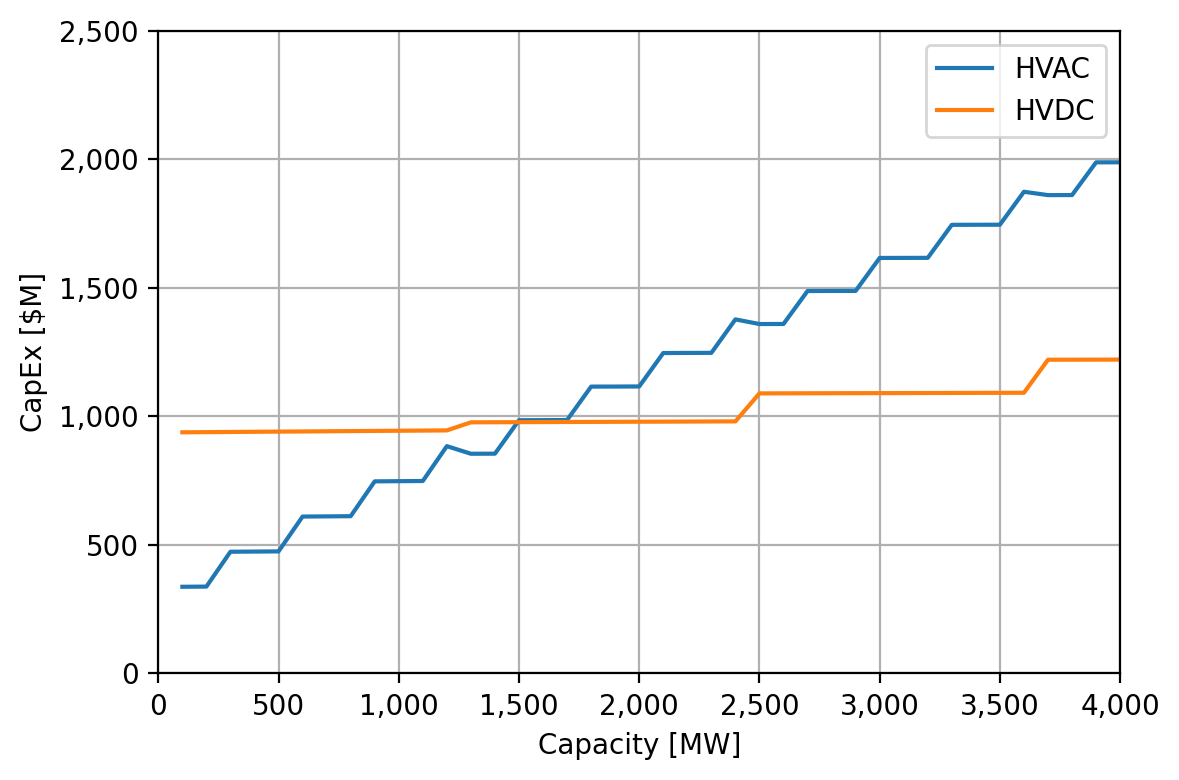

In [9]:
fig = plt.figure(figsize=(6,4), dpi=200)
ax = fig.subplots(1)

ax.plot(
    hvac_df["plant.capacity"],
    (hvac_df["cable_cost"] + hvac_df["oss_cost"]) / 1e6,
    label="HVAC"
)

ax.plot(
    hvdc_df["plant.capacity"],
    (hvdc_df["cable_cost"] + hvdc_df["oss_cost"]) / 1e6,
    label="HVDC",
)

ax.set_xlim(0, capacity_range.max())
ax.set_ylim(0, 2500)

ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.set_ylabel("CapEx [$M]")
ax.set_xlabel("Capacity [MW]")
ax.legend()
ax.grid()

fig.tight_layout()

Comparing the below figure to the CapEx figure above, highlights that CapEx increases for the HVDC
system correspond to an increase in the number of substations (each requires a single cable),
whereas for HVAC system, these increases primarily correspond to an increase in the number of export
cables with a smaller increase stemming from the substation requiremensts.

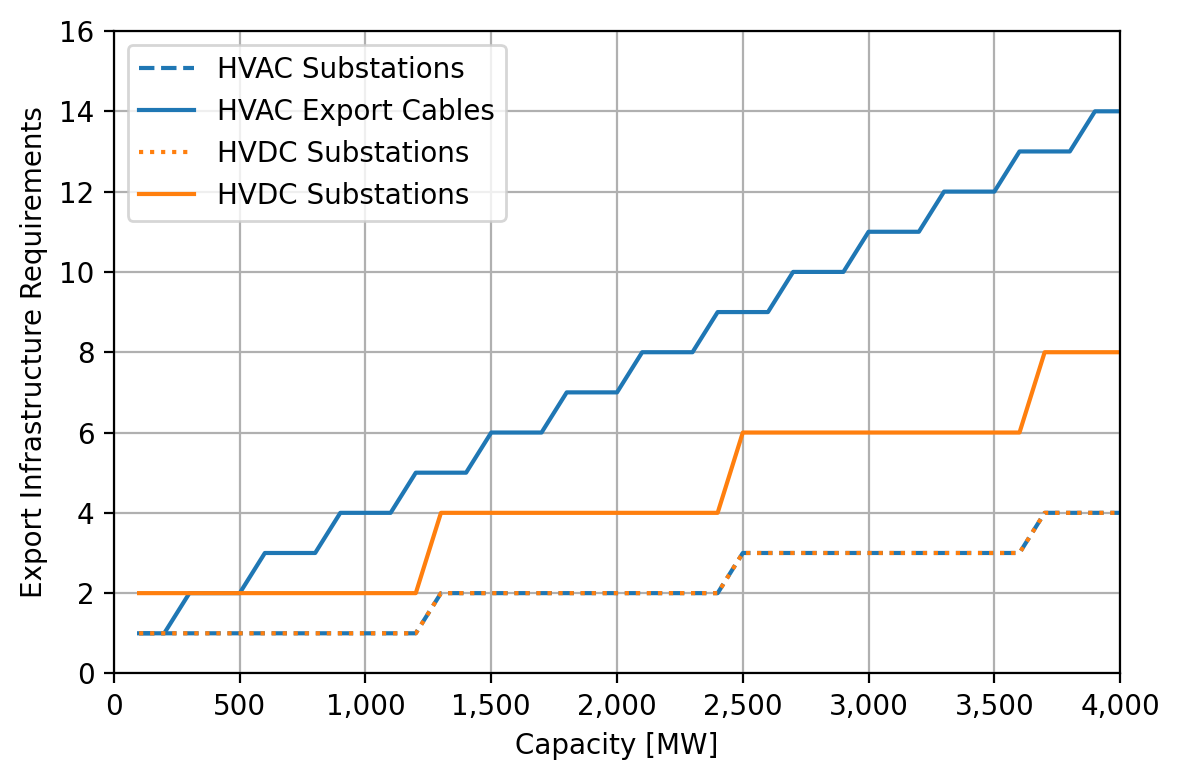

In [10]:
fig = plt.figure(figsize=(6,4), dpi=200)
ax = fig.subplots(1)

ax.plot(hvac_df["plant.capacity"], hvac_df["num_substations"], c="tab:blue", ls="--", label="HVAC Substations")
ax.plot(hvac_df["plant.capacity"], hvac_df["num_cables"], c="tab:blue", ls="-", label="HVAC Export Cables")
ax.plot(hvdc_df["plant.capacity"], hvdc_df["num_substations"], c="tab:orange", ls="dotted", label="HVDC Substations")
ax.plot(hvdc_df["plant.capacity"], hvdc_df["num_cables"], c="tab:orange", ls="-", label="HVDC Substations")

ax.set_xlim(0, capacity_range.max())
ax.set_ylim(0, 16)

ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

ax.set_xlabel("Capacity [MW]")
ax.set_ylabel("Export Infrastructure Requirements")
ax.legend()
ax.grid()

fig.tight_layout()